# Phase 5: Modeling Scaffold

This notebook is designed to let each team member **hot‑swap their own model** (Logistic Regression, Perceptron, LinearSVC, RidgeClassifier, shallow neural nets, etc.) while keeping the **evaluation pipeline hardened**.

- **Hardened cells**: infrastructure, data loading, label encoding, evaluation functions.  
- **Editable cells**: model definition, hyperparameters, feature set choice.  


## Section 1: Imports (Hardened)

Do not edit unless you need additional libraries.  
This cell provides the common imports for all models and evaluations.


In [29]:
import pandas as pd
import numpy as np
from scipy import sparse
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
from sklearn.model_selection import StratifiedKFold, cross_val_score


## Section 2: Load Artifacts (Hardened)

Do not edit file paths unless Phase 3 outputs change.  
This cell loads the lexicon-only and hybrid-weighted feature sets, plus labels.


In [30]:
X_train_lex = sparse.load_npz("Phase_3/X_train_lexicon.npz").toarray()
X_val_lex   = sparse.load_npz("Phase_3/X_val_lexicon.npz").toarray()

# Use the actual hybrid files you have
X_train_hybrid = sparse.load_npz("Phase_3/X_train_hybrid.npz")
X_val_hybrid   = sparse.load_npz("Phase_3/X_val_hybrid.npz")

y_train = pd.read_csv("Phase_3/labels_train.csv")["Sentiment"]
y_val   = pd.read_csv("Phase_3/labels_val.csv")["Sentiment"]

print("Lexicon train shape:", X_train_lex.shape)
print("Hybrid train shape:", X_train_hybrid.shape)
print("Train label distribution:\n", y_train.value_counts())
print("Val label distribution:\n", y_val.value_counts())


Lexicon train shape: (409577, 4)
Hybrid train shape: (409577, 3004)
Train label distribution:
 Sentiment
positive    235384
negative    124820
neutral      49373
Name: count, dtype: int64
Val label distribution:
 Sentiment
positive    502
negative    478
neutral      20
Name: count, dtype: int64


## Section 3: Encode Labels (Hardened)

Do not edit.  
This ensures consistent label encoding across all models.


In [31]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)

print("Classes:", list(le.classes_))

Classes: ['negative', 'neutral', 'positive']


## Section 4: Model Definition (Editable)

This is the **open cell**.  
Each team member should define their own model here.  
Examples:
- LogisticRegression(penalty='l2')
- LogisticRegression(penalty='l1', solver='saga')
- Perceptron()
- LinearSVC()
- RidgeClassifier()
- MLPClassifier(hidden_layer_sizes=(100,), activation='relu')

⚠️ Only edit inside this cell. The rest of the notebook will use whatever `model` you define here.


from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    solver='lbfgs'   # or 'saga' if you want L1/L2 flexibility
)


In [32]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression

class PreprocLogReg(BaseEstimator, ClassifierMixin):
    """
    Wrapper: TruncatedSVD -> LogisticRegression (L1 or L2)

    Purpose:
    - Stabilize Logistic Regression on high-dimensional sparse text features
    - Allow fair comparison with Fisher (SVD + LDA)
    - Maintain GridSearchCV and CV compatibility
    """

    def __init__(self,
                 svd_n_components=100,
                 svd_random_state=42,
                 penalty="l2",
                 C=1.0,
                 solver="lbfgs",
                 class_weight="balanced",
                 max_iter=3000):
        self.svd_n_components = svd_n_components
        self.svd_random_state = svd_random_state
        self.penalty = penalty
        self.C = C
        self.solver = solver
        self.class_weight = class_weight
        self.max_iter = max_iter

        self._svd = None
        self._clf = None

    def _cap_n_components(self, X):
        n_features = X.shape[1]
        return max(1, min(int(self.svd_n_components), n_features))

    def fit(self, X, y):
        n_comp = self._cap_n_components(X)

        self._svd = TruncatedSVD(
            n_components=n_comp,
            random_state=self.svd_random_state
        )
        X_reduced = self._svd.fit_transform(X)

        self._clf = LogisticRegression(
            penalty=self.penalty,
            C=self.C,
            solver=self.solver,
            class_weight=self.class_weight,
            max_iter=self.max_iter,
            n_jobs=-1
        )
        self._clf.fit(X_reduced, y)
        return self

    def predict(self, X):
        X_reduced = self._svd.transform(X)
        return self._clf.predict(X_reduced)

    def predict_proba(self, X):
        X_reduced = self._svd.transform(X)
        return self._clf.predict_proba(X_reduced)

    def get_params(self, deep=True):
        return {
            "svd_n_components": self.svd_n_components,
            "svd_random_state": self.svd_random_state,
            "penalty": self.penalty,
            "C": self.C,
            "solver": self.solver,
            "class_weight": self.class_weight,
            "max_iter": self.max_iter
        }

    def set_params(self, **params):
        for k, v in params.items():
            setattr(self, k, v)
        return self


In [33]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    penalty="l1",
    C=1.0,
    solver="saga",
    max_iter=3000,
    class_weight="balanced",
    n_jobs=-1
)


In [34]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=2000,
    class_weight="balanced",
    n_jobs=-1
)


## Section 4a: Hyperparameter Tuning (Editable)

Do not edit.  
This cell runs GridSearchCV on the model defined in Section 4, using `f1_macro` as the scoring metric.  
It will search across a parameter grid appropriate for linear models (LogisticRegression, LinearSVC, RidgeClassifier, Perceptron).


In [35]:
from sklearn.model_selection import GridSearchCV

# Parameter grids for common linear models
param_grids = {
    "LogisticRegression": {
        "C": [0.01, 0.1, 1, 10],
        "penalty": ["l2"],        # or ["l1", "l2", "elasticnet"] if saga solver
        "solver": ["lbfgs", "saga"]
    },
    "PreprocLogReg": {
        "svd_n_components": [50, 100, 200],
        "penalty": ["l1", "l2"],
        "C": [0.01, 0.1, 1, 10],
        "solver": ["lbfgs", "saga"]
    },
    "LinearSVC": {
        "C": [0.01, 0.1, 1, 10],
        "loss": ["hinge", "squared_hinge"]
    },
    "RidgeClassifier": {
        "alpha": [0.1, 1.0, 10.0]
    },
    "Perceptron": {
        "penalty": [None, "l2", "l1", "elasticnet"],
        "alpha": [0.0001, 0.001, 0.01]
    }
}

# Detect model type and select grid
model_name = model.__class__.__name__
param_grid = param_grids.get(model_name, {})

if param_grid:
    grid = GridSearchCV(
        estimator=model.__class__(**model.get_params()),
        param_grid=param_grid,
        scoring="f1_macro",
        cv=3,
        n_jobs=-1
    )
    grid.fit(X_train_lex, y_train_enc)
    print(f"Best params for {model_name}:", grid.best_params_)
    print(f"Best CV Macro-F1 for {model_name}:", grid.best_score_)
else:
    print(f"No parameter grid defined for {model_name}. Please add one to param_grids.")


Best params for LogisticRegression: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV Macro-F1 for LogisticRegression: 0.40628666765421745


## Section 5: Evaluation Functions (Hardened)

Do not edit.  
These functions handle training, evaluation, metrics, and cross-validation consistently.


In [36]:
def train_and_evaluate(model, X_train, X_val, y_train_enc, y_val_enc, le, name):
    model.fit(X_train, y_train_enc)
    y_pred = model.predict(X_val)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_val)
        roc_auc = roc_auc_score(y_val_enc, y_proba, multi_class='ovr')
    else:
        y_proba = None
        roc_auc = None

    print(f"\n=== {name} Results ===")
    print("Accuracy:", accuracy_score(y_val_enc, y_pred))
    print("Macro Precision:", precision_score(y_val_enc, y_pred, average='macro'))
    print("Macro Recall:", recall_score(y_val_enc, y_pred, average='macro'))
    print("Macro F1 Score:", f1_score(y_val_enc, y_pred, average='macro'))
    if roc_auc is not None:
        print("ROC-AUC:", roc_auc)
    print("\nConfusion Matrix:\n", confusion_matrix(y_val_enc, y_pred))
    print("\nClassification Report:\n", classification_report(y_val_enc, y_pred, target_names=le.classes_))

    f1_per_class = f1_score(y_val_enc, y_pred, average=None)
    print("Per-class F1:", dict(zip(le.classes_, f1_per_class)))

    return model

def cross_validate_model(model, X_train, y_train_enc, name):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train_enc, cv=cv, scoring='f1_macro')
    print(f"\n{name} 5-Fold CV Macro-F1 Scores:", cv_scores)
    print(f"{name} Mean Macro-F1 Score:", cv_scores.mean())


## Section 6: Run Tracks (Hardened)

Do not edit.  
This runs the chosen model on both lexicon-only and hybrid-weighted feature sets.


In [37]:
# Fresh model instances for each track
model_lex = train_and_evaluate(
    model.__class__(**model.get_params()),  # clone model
    X_train_lex, X_val_lex, y_train_enc, y_val_enc, le, "Lexicon-only"
)
cross_validate_model(model.__class__(**model.get_params()), X_train_lex, y_train_enc, "Lexicon-only")

model_hybrid = train_and_evaluate(
    model.__class__(**model.get_params()),  # clone model
    X_train_hybrid, X_val_hybrid, y_train_enc, y_val_enc, le, "Hybrid"
)
cross_validate_model(model.__class__(**model.get_params()), X_train_hybrid, y_train_enc, "Hybrid")



=== Lexicon-only Results ===
Accuracy: 0.91
Macro Precision: 0.8540387786320203
Macro Recall: 0.9375718881794995
Macro F1 Score: 0.8849433736566921
ROC-AUC: 0.9874248185337885

Confusion Matrix:
 [[398   8  72]
 [  0  20   0]
 [ 10   0 492]]

Classification Report:
               precision    recall  f1-score   support

    negative       0.98      0.83      0.90       478
     neutral       0.71      1.00      0.83        20
    positive       0.87      0.98      0.92       502

    accuracy                           0.91      1000
   macro avg       0.85      0.94      0.88      1000
weighted avg       0.92      0.91      0.91      1000

Per-class F1: {'negative': 0.8984198645598194, 'neutral': 0.8333333333333334, 'positive': 0.9230769230769231}

Lexicon-only 5-Fold CV Macro-F1 Scores: [0.40445101 0.40951727 0.40358162 0.40755926 0.40623675]
Lexicon-only Mean Macro-F1 Score: 0.40626918011947366

=== Hybrid Results ===
Accuracy: 0.806
Macro Precision: 0.6277463339635901
Macro Recall:

## Section 7: Comparison Visualization (Hardened)

Do not edit.  
This shows side-by-side Macro-F1 scores for lexicon-only vs hybrid-weighted.


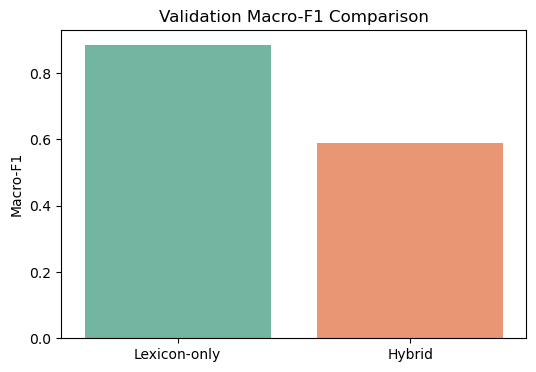

In [38]:
results = {
    "Lexicon-only": f1_score(y_val_enc, model_lex.predict(X_val_lex), average='macro'),
    "Hybrid": f1_score(y_val_enc, model_hybrid.predict(X_val_hybrid), average='macro')
}

plt.figure(figsize=(6,4))
sns.barplot(x=list(results.keys()), y=list(results.values()),
            palette="Set2", hue=list(results.keys()), legend=False)

plt.title("Validation Macro-F1 Comparison")
plt.ylabel("Macro-F1")
plt.show()


## Section 8: Team notes / experiments (Editable)

This cell is left empty for team members to jot down observations, experiments, or additional metrics.


In [39]:
# Team notes / experiments here
